# FOL-Triage: screening a three-layer, gold-free checker for NL→FOL translations

This notebook is a runnable demo of **experiment A (iteration 1)** of the FOL-Triage project. The question is how to score a
candidate first-order-logic (FOL) translation of an English sentence for **faithfulness to the text**, with **no gold
formula**, no ontology and no domain knowledge.

The checker has three layers. Each one looks only at the `(text, fol)` pair:

| layer | what it measures | cost |
|---|---|---|
| **L1 `fol_lint`** | text-free formula "smells", e.g. `∃x(A→B)`, `∀x(A∧B)`, free or dangling variables, vacuous or trivial formulas (z3) | CPU |
| **L2-bow `content_accounting`** | predicates that no text word anchors (ADD) and text content words that no predicate carries (DROP) | CPU |
| **L2-role `role_accounting`** | spaCy roles of text words (condition / asserted / exception, negation) against the exact z3 monotonicity of the aligned predicates | CPU |
| **L3 `role_questionnaire` + `l3_compare`** | a small LLM (gemini-2.5-flash-lite) reads **only the sentence** and fills a frozen role schema. That schema is compared field by field with the formula's exact z3 role profile | ≈ $0.0002 / item |

A **fused logistic** model combines the layer features. It is fitted on track **H** (human original→corrected FOLIO/MALLS
annotations) plus **HREF** (corrected gold used as known-correct candidates), and is then applied to track **L**: real
Logic-LM outputs of gpt-3.5 / gpt-4 / davinci-003 on FOLIO-dev, labelled against DSAVlab-corrected gold.

**What the notebook runs:** the original `method.py` stages **4 → 7** (pre-registration → calibration on H+HREF → blind
scoring of L → invariance, decomposed-judge and nonce-disguise ablations → label join and AUROC). The code is copied from the
original script with minimal changes. Heavy inputs are **pre-computed and packed into `mini_demo_data.json`**: the z3/spaCy
layer outputs and the cached LLM answers. The notebook therefore needs no API key and makes no solver calls. The
released `l3_compare` comparison itself is re-executed here.

**Scale:** the demo uses a curated 100-item subset (35 H + 40 L + 25 HREF). The full run used 302 H + 753 L + 302 HREF.
AUROCs on 16-vs-16 items are very noisy, so the last cell sets them beside the full-run numbers.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, scikit-learn, nltk, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'nltk==3.9.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import asyncio
import hashlib
import json
import math
import pickle
import resource
import sys
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
from loguru import logger

ROOT = Path(".").resolve()  # notebook: working directory instead of the script folder (no src/ needed)
sys.setrecursionlimit(10000)
(ROOT / "logs").mkdir(exist_ok=True)
(ROOT / "results").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")  # notebook: stdout only
# resource.setrlimit(resource.RLIMIT_AS, (20 * 1024**3, 20 * 1024**3))  # original 20 GB cap; the demo needs <1 GB

# The original script imports its helpers from src/:
#   from pipeline import (scoring_view, run_cpu_layers, run_questionnaires, run_decomposed, run_profiles,
#                         prof_from_json, sha1, ledger_total, safe_log_words)
#   from screen import norm
#   import fol_triage as FT
# In the notebook, the pure-Python parts of these modules are copied verbatim into cells below. The z3 / spaCy / LLM
# stages are replaced by lookups into the pre-computed outputs stored in mini_demo_data.json.
import re
import itertools
import types
from functools import lru_cache

import nltk
from nltk.stem import PorterStemmer
nltk.download('wordnet', quiet=True)  # WordNet backs the lexical predicate<->phrase alignment in l3_compare
from nltk.corpus import wordnet as wn

import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-1/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(json.dumps(data["metadata"], indent=1))

{
 "description": "Curated 100-item subset of the FOL-Triage frozen screen (75 track H/L items + 25 HREF corrected-gold items) with every cached layer output needed to rerun method.py stages 5-7 without z3/spaCy/LLM calls.",
 "counts": {
  "H": 35,
  "L": 40,
  "HREF": 25,
  "invariance_rows": 40
 },
 "labels_H": {
  "ERROR": 9,
  "UNCERTAIN": 8,
  "CORRECT": 18
 },
 "labels_L": {
  "CORRECT": 16,
  "UNCERTAIN": 4,
  "ERROR": 16,
  "UNPARSEABLE": 4
 },
 "systems_L": {
  "gpt-3.5-turbo": 16,
  "gpt-4": 12,
  "text-davinci-003": 12
 },
 "models": {
  "PRIMARY": "google/gemini-2.5-flash-lite",
  "SECOND": "qwen/qwen3-30b-a3b-instruct-2507",
  "LOCAL": "local/qwen2.5-1.5b-instruct-q4_k_m"
 }
}


## Configuration

These are all the tunable parameters. `N_H`, `N_L` and `N_HREF` take a prefix of each track from the mini data. The mini
data holds at most 35 / 40 / 25; the original run used all 302 / 753 / 302. `B_BOOT` is the number of sentence-clustered
bootstrap resamples behind the AUROC confidence intervals (the original uses 2000). `FUSION_C` and `PREVALENCES` are the
frozen, pre-registered values from `method.py`.

In [5]:
N_H = 35        # track-H items used for calibration / fusion training (max 35 in mini data; original: all 302)
N_L = 40        # track-L items scored blind and evaluated (max 40 in mini data; original: all 753)
N_HREF = 25     # HREF corrected-gold items (known-correct candidates) (max 25 in mini data; original: all 302)
B_BOOT = 2000   # cluster-bootstrap resamples for AUROC CIs (original: 2000)
FUSION_C = 1.0  # L2 strength of the fused logistic regression (frozen in prereg)
PREVALENCES = [0.10, 0.25]  # prevalences for re-weighted precision (frozen in prereg)

## Constants from `method.py`

These are the model identifiers and the seven fusion features. `PRIMARY` is the L3 model. `SECOND` (a second cheap model)
and `LOCAL` (the local Qwen2.5-1.5B used during an OpenRouter outage) are robustness rows. `DRY` is set to 0, and the demo
writes its outputs to `demo_results/`.

In [6]:
PRIMARY = "google/gemini-2.5-flash-lite"
SECOND = "qwen/qwen3-30b-a3b-instruct-2507"  # planned 2nd cheap model (robustness row on HREF)
LOCAL = "local/qwen2.5-1.5b-instruct-q4_k_m"  # outage fallback, cache-only robustness row
FEATS = ["l1_any", "n_smells", "bow_uncarried", "bow_n_unanch", "role_count", "l3_score", "log_words"]
# FUSION_C, PREVALENCES, B_BOOT are set in the config cell above
import os  # noqa: E402
DRY = 0  # T6 dry run: small subsets, separate output dir, never touches prereg.json
RES = ROOT / "demo_results"  # notebook output dir
RES.mkdir(exist_ok=True)
PREREG = RES / "prereg.json"  # notebook: kept inside demo_results/
if PREREG.exists():
    PREREG.unlink()  # notebook: every run re-freezes its own prereg + calibration


def sha256f(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()


def load_json(p):
    return json.loads(Path(p).read_text())

## Pipeline helpers: pre-computed layer outputs instead of z3, spaCy and LLM calls

In the original script, `src/pipeline.py` runs the CPU layers in a process pool: z3 profiles, the L1 lint, spaCy L2-role
and WordNet L2-bow. It also runs the LLM questionnaires through OpenRouter, and both steps cache their results.
The demo replaces these runners with **lookups of the same cached records**, copied for the 100 demo items into
`mini_demo_data.json` by `build_mini_data.py`. The small pure helpers (`sha1`, `scoring_view`, `prof_from_json`,
`safe_log_words`, `norm`) are copied verbatim. A missing cached answer produces the same `L3_MISSING` record that
the original's `CacheMiss` branch produces.

In [7]:
# ---- verbatim from src/pipeline.py and src/screen.py
LABEL_KEYS = ("label", "auto_class", "repair_ops")


def sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()


def scoring_view(items: list[dict]) -> list[dict]:
    """Items stripped of every label field; asserts the keys are absent (scoring code can only see this view)."""
    out = [{k: v for k, v in x.items() if k not in LABEL_KEYS} for x in items]
    for x in out:
        assert not any(k in x for k in LABEL_KEYS)
    return out


def prof_from_json(p: dict | None) -> dict | None:
    if p is None:
        return None
    return {k: {**v, "slots": [tuple(s) for s in v["slots"]]} for k, v in p.items()}


def safe_log_words(text: str) -> float:
    return math.log(max(1, len(text.split())))


def norm(t: str) -> str:
    t = t.lower().replace("’", "'").replace("‘", "'")
    t = re.sub(r"(\w)'(\w)", r"\1\2", t)  # inner apostrophes removed
    t = re.sub(r"[^\w\s]", " ", t)
    return " ".join(t.split())


# ---- notebook stand-ins for the cached z3/spaCy/LLM runners (same return shapes as src/pipeline.py)
def run_cpu_layers(pairs):
    """pairs [(text, fol)] -> {sha1(text|fol): L1 / L2-bow / L2-role / z3-profile record} (pre-computed)."""
    return {sha1(f"{t}|{f}"): data["cpu_layers"][sha1(f"{t}|{f}")] for t, f in pairs}


def run_questionnaires(texts, model, tag="L3"):
    """{text: {'q': validated L3 schema | None, 'coverage_status', 'cost_usd', 'secs', ...}} from the cached answers."""
    qa = data["questionnaires"].get(f"{model}|{tag}", {})
    return {t: qa.get(t, {"q": None, "coverage_status": "L3_MISSING", "cost_usd": 0.0, "secs": 0.0})
            for t in dict.fromkeys(texts)}


def run_decomposed(pairs, model):
    """{(text, fol): {'profile': LLM-read formula profile, 'status', 'cost_usd'}} (decomposed-judge ablation)."""
    dj = {(r["text"], r["fol"]): {**r, "profile": prof_from_json(r["profile"])} for r in data["decomposed"]}
    return {(t, f): dj.get((t, f), {"profile": None, "status": "DJ_MISSING", "cost_usd": 0.0}) for t, f in pairs}


_DFOL = {(r["fol"], json.dumps(data["disguise_text"][r["text"]][1], sort_keys=True)): r for r in data["disguise_formula"]}


def lemma_map(text):
    """-> (nonce-disguised text, {porter_stem: nonce}) (src/disguise.py, pre-computed with spaCy)."""
    dt, m = data["disguise_text"][text]
    return dt, m


def disguise_formula(fol, stem_map):
    """formula with the same lemma->nonce map applied to predicate / constant names (pre-computed)."""
    return _DFOL[(fol, json.dumps(stem_map, sort_keys=True))]["disguised_fol"]


def run_profiles(fols):
    """{disguised formula: exact z3 role profile} (pre-computed)."""
    pr = {r["disguised_fol"]: prof_from_json(r["disguised_profile"]) for r in data["disguise_formula"]}
    return {f: pr.get(f) for f in fols}


def ledger_total() -> float:
    return 0.0  # notebook: no LLM call is made, so there is no new spend (the full run spent $0.29 in total)

## Released L3 comparison functions (`src/fol_triage.py`, verbatim)

L3 is the core idea. Correct FOL is not unique, so the checker does **not** compare the formula with a gold formula. It compares
two *role descriptions* of the same content:

* **text side:** a small LLM reads only the sentence and lists its concepts. For each concept it gives the role
  (condition / asserted / background), negation, exception, quantifier force and claim index, plus the argument order of
  each relation.
* **formula side:** `formula_role_profile` answers the same questions **exactly** with z3. Each predicate gets its
  monotonicity (DOWN = condition, UP = asserted), local negation, quantifier force, claim and argument slots.

`align_concepts` pairs text phrases with predicate names through Porter stems and WordNet. `l3_compare` then returns
one mismatch fraction per field: `mm_role`, `mm_force`, `mm_claims`, `mm_order`, `mm_exception`, `missing_frac` and
`extra_frac`. `l3_score` sums the fields that passed the HREF accuracy gate. The cell below also holds the frozen L3 prompt
and schema, which are recorded in the pre-registration.

In [8]:
# ---- from src/content_accounting.py (lexicons + WordNet lexical expansion)
PS = PorterStemmer()
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
FUNC = set("""a an the and or but nor not no none neither either both all every each any some several many much more most
less least few if then else when whenever while whereas unless except only also too than that which who whom whose what where
is are was were be been being am do does did done has have had having can could may might must shall should will would of in
on at to for from by with without into onto over under about as it its they them their there this these those he she him her
his hers we us our you your i me my one ones such same other another own so very just often usually typically generally
sometimes always never also either neither something someone somebody anything anyone everything everyone thing things
be is s t""".split())
HEDGE = {"often", "usually", "typically", "generally", "sometimes", "can", "could", "may", "might", "likely", "probably",
         "tend", "tends", "mostly", "commonly", "frequently", "normally"}
SORTAL = {"person", "people", "thing", "entity", "object", "individual", "human", "someone", "something"}




def name_words(name):
    return [w.lower() for w in TOKRE.findall(name.replace("_", " ")) if w.lower() not in FUNC and len(w) > 1]


_lex_cache = {}


def lex(w):
    """stem-level expansion of w: its stem, WordNet lemmas of its synsets, derivationally related forms."""
    if w in _lex_cache:
        return _lex_cache[w]
    out = {PS.stem(w)}
    for pos in ("n", "v", "a", "r"):
        m = wn.morphy(w, pos)
        if m:
            out.add(PS.stem(m))
    for s in wn.synsets(w)[:4]:
        for l in s.lemmas()[:6]:
            n = l.name().lower()
            if "_" not in n:
                out.add(PS.stem(n))
            for d in l.derivationally_related_forms()[:4]:
                if "_" not in d.name():
                    out.add(PS.stem(d.name().lower()))
    _lex_cache[w] = out
    return out


ca = types.SimpleNamespace(PS=PS, FUNC=FUNC, HEDGE=HEDGE, SORTAL=SORTAL, name_words=name_words, lex=lex)

# ---- from src/fol_triage.py
LOGIC_WORDS = {"all", "every", "each", "any", "some", "no", "not", "none", "if", "then", "only", "unless", "except",
               "either", "or", "and", "neither", "nor", "both", "never", "always", "there", "exists"}


@lru_cache(maxsize=None)
def name_words(name: str) -> tuple:
    return tuple(ca.name_words(name))


@lru_cache(maxsize=None)
def _lex(w: str) -> frozenset:
    return frozenset(ca.lex(w))


def word_match(w: str, pw: str, exact: bool = False) -> bool:
    """Text word w matches predicate-name word pw: same Porter stem (exact) or WordNet lemma/synonym/derivation."""
    sw, sp = PS.stem(w.lower()), PS.stem(pw.lower())
    if sw == sp:
        return True
    if exact:
        return False
    return sp in _lex(w.lower()) or sw in _lex(pw.lower())


def const_match(phrase_words: list[str], const: str) -> bool:
    c = re.sub(r"[^a-z0-9]", "", const.lower())
    p = re.sub(r"[^a-z0-9]", "", "".join(phrase_words).lower())
    if not c or not p:
        return False
    return c == p or (len(p) >= 3 and (c.startswith(p) or p.startswith(c) or p in c))



COND_MARKS = ("if", "when", "whenever", "once", "provided", "as long as", "in case", "assuming", "given that")
EXC_MARKS = ("unless", "except", "excluding", "without", "but not", "other than")
GENERIC_DETS = {"all", "every", "each", "any", "no"}
GENERIC_PRON = {"everyone", "anyone", "everybody", "anybody", "everything", "anything", "nobody", "whoever", "those"}
NEG_WORDS = {"not", "n't", "never", "no", "none", "nobody", "nothing", "neither", "nor", "cannot"}

L3_SCHEMA_TEXT = """{"concepts": [{"id": "c1", "phrase": "<exact words copied from the sentence>", "role": "condition" | "asserted" | "background", "negated": true | false, "exception": true | false, "force": "all" | "some" | "named" | "none", "claim": <int>}], "relations": [{"phrase": "<verb or relational words>", "first": "<concept id>", "second": "<concept id>"}]}"""

L3_SYSTEM = """You analyse the logical structure of ONE English sentence. You never see any formula. Return ONLY a JSON object with this schema:
""" + L3_SCHEMA_TEXT + """

Field definitions:
- concepts: every property, class, action, relation word-group or named individual the sentence talks about. "phrase" = the SHORTEST span of the sentence's own words naming it (e.g. "barks", "dog", "loud", "chases", "Mia"). Relation verbs are concepts too.
- role: "condition" = restricts WHO/WHEN the statement applies to (subject class of a general statement such as "every dog", words inside a relative clause on that subject, an if/when clause, the restricting part of an "only ... if"); "asserted" = what the sentence claims holds (main predicate, the then-part); "background" = named individuals, or words that are neither.
- negated: true if the sentence says the concept does NOT hold (not, never, no, none, cannot) for it, taken literally where it appears. For "No A is B", A is a condition with negated=false and B is asserted with negated=true.
- exception: true only for concepts introduced by unless / except / other than / without / but not.
- force: how the thing the concept is said of is quantified: "all" (every, all, any, bare plural generic, if-something), "some" (some, a certain, there is, at least one), "named" (said of a named individual), "none" (does not apply).
- claim: statements that could be true or false independently get different integers (1, 2, ...); concepts of the same statement share the claim number.
- relations: for every two-place relation, "first" is the concept id of the one who DOES / HAS the relation (logical subject, also in passive voice: "X is liked by Y" -> first = Y), "second" is the one it is done to. A named individual is its own concept.

Worked examples (not from any benchmark):
1. "Every dog that barks is loud unless it is asleep."
{"concepts":[{"id":"c1","phrase":"dog","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c2","phrase":"barks","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c3","phrase":"loud","role":"asserted","negated":false,"exception":false,"force":"all","claim":1},{"id":"c4","phrase":"asleep","role":"condition","negated":false,"exception":true,"force":"all","claim":1}],"relations":[]}
2. "No teacher who owns a bicycle drives to work."
{"concepts":[{"id":"c1","phrase":"teacher","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c2","phrase":"owns","role":"condition","negated":false,"exception":false,"force":"all","claim":1},{"id":"c3","phrase":"bicycle","role":"condition","negated":false,"exception":false,"force":"some","claim":1},{"id":"c4","phrase":"drives to work","role":"asserted","negated":true,"exception":false,"force":"all","claim":1}],"relations":[{"phrase":"owns","first":"c1","second":"c3"}]}
3. "Mia is not a painter, and Leo admires Mia."
{"concepts":[{"id":"c1","phrase":"Mia","role":"background","negated":false,"exception":false,"force":"named","claim":1},{"id":"c2","phrase":"painter","role":"asserted","negated":true,"exception":false,"force":"named","claim":1},{"id":"c3","phrase":"Leo","role":"background","negated":false,"exception":false,"force":"named","claim":2},{"id":"c4","phrase":"admires","role":"asserted","negated":false,"exception":false,"force":"named","claim":2}],"relations":[{"phrase":"admires","first":"c3","second":"c1"}]}
4. "Some kettles are made of copper, and if a kettle is made of copper then it is heavy."
{"concepts":[{"id":"c1","phrase":"kettles","role":"asserted","negated":false,"exception":false,"force":"some","claim":1},{"id":"c2","phrase":"made of copper","role":"asserted","negated":false,"exception":false,"force":"some","claim":1},{"id":"c3","phrase":"kettle","role":"condition","negated":false,"exception":false,"force":"all","claim":2},{"id":"c4","phrase":"made of copper","role":"condition","negated":false,"exception":false,"force":"all","claim":2},{"id":"c5","phrase":"heavy","role":"asserted","negated":false,"exception":false,"force":"all","claim":2}],"relations":[]}
Output the JSON object only, compact on ONE line (no indentation, no newlines)."""


# =============================================================================================== L3 compare
def phrase_words(phrase: str) -> list[str]:
    ws = re.findall(r"[A-Za-z]+|\d+", phrase)
    return [w.lower() for w in ws if w.lower() not in ca.FUNC and w.lower() not in ca.HEDGE and len(w) > 1
            and w.lower() not in LOGIC_WORDS] or [w.lower() for w in ws if len(w) > 1][:1]


def align_concepts(q: dict, prof: dict, exact: bool = False) -> dict:
    """concept id -> ('pred', key) | ('const', name) | None.  Predicate match: overlap coefficient of phrase content
    words vs predicate-name words (match = same stem or WordNet link; exact=True -> stem only) >= 0.5, ties broken by
    Jaccard; named individuals may match a constant by normalised string."""
    consts = sorted({s[1] for p in prof.values() for s in p["slots"] if s[0] == "const"})
    out = {}
    for c in q["concepts"]:
        pw = phrase_words(c["phrase"])
        best, bs = None, (0.0, 0.0)
        if c["force"] == "named" or c["role"] == "background":
            for k in consts:
                if const_match(re.findall(r"[A-Za-z0-9]+", c["phrase"]), k):
                    best = ("const", k)
                    break
            if best:
                out[c["id"]] = best
                continue
        for k, p in prof.items():
            nw = name_words(p["name"])
            if not nw or not pw:
                continue
            m_p = sum(any(word_match(w, x, exact) for w in pw) for x in nw)
            m_t = sum(any(word_match(w, x, exact) for x in nw) for w in pw)
            m = min(m_p, m_t) if min(m_p, m_t) > 0 else 0
            if m == 0:
                continue
            ov = m / min(len(nw), len(pw))
            jac = m / (len(nw) + len(pw) - m)
            if ov >= 0.5 and (ov, jac) > bs:
                best, bs = ("pred", k), (ov, jac)
        out[c["id"]] = best
    return out


def _rand_index(a: list, b: list) -> float | None:
    n = len(a)
    if n < 2:
        return None
    agree = tot = 0
    for i, j in itertools.combinations(range(n), 2):
        tot += 1
        agree += (a[i] == a[j]) == (b[i] == b[j])
    return agree / tot


def expected_mono(role: str, negated: bool, exception: bool) -> str | None:
    if role == "background":
        return None
    base = "DOWN" if role == "condition" else "UP"
    if exception:
        base = "UP"
    if negated:
        base = "UP" if base == "DOWN" else "DOWN"
    return base


L3_FIELDS = ["mm_role", "mm_force", "mm_claims", "mm_order", "mm_exception", "missing_frac", "extra_frac"]


def l3_compare(q: dict, prof: dict, exact: bool = False) -> dict:
    """Per-field mismatch between the text questionnaire q and a formula profile (z3 or LLM-read).
    Returns fractions in [0,1] (None when the field has no applicable concept) plus counts and alignment stats."""
    al = align_concepts(q, prof, exact)
    cons = {c["id"]: c for c in q["concepts"]}
    role_n = role_bad = force_n = force_bad = exc_n = exc_bad = 0
    tp, fp_ = [], []
    for c in q["concepts"]:
        a = al.get(c["id"])
        if not a or a[0] != "pred":
            continue
        p = prof[a[1]]
        exp = expected_mono(c["role"], c["negated"], c["exception"])
        if exp is not None and p["mono"] in ("UP", "DOWN"):
            role_n += 1
            role_bad += exp != p["mono"]
        if c["force"] in ("all", "some", "named") and p["force"] in ("all", "some", "named"):
            force_n += 1
            force_bad += c["force"] != p["force"]
        if c["exception"]:
            exc_n += 1
            ok = p["mono"] == "UP" or (p["pos"] == "antecedent" and p["local_neg"])
            exc_bad += not ok
        tp.append(c["claim"]); fp_.append(p["claim"])
    ri = _rand_index(tp, fp_)
    ord_n = ord_bad = 0
    for r in q["relations"]:
        rc = {"id": "_r", "phrase": r["phrase"], "role": "asserted", "force": "all", "negated": False, "exception": False,
              "claim": 0}
        ra = align_concepts({"concepts": [rc]}, {k: v for k, v in prof.items() if v["arity"] == 2}, exact).get("_r")
        if not ra:
            continue
        p = prof[ra[1]]
        a1, a2 = al.get(r["first"]), al.get(r["second"])

        def hit(aa, slot):
            if not aa or slot[1] is None:
                return False
            if aa[0] == "const":
                return slot == ("const", aa[1])
            return slot[0] == "var" and prof.get(aa[1], {}).get("name") == slot[1]
        s = p["slots"]
        f0, f1 = hit(a1, s[0]), hit(a1, s[1])
        g0, g1 = hit(a2, s[0]), hit(a2, s[1])
        if (f0 or g1) and not (f1 and g0):
            ord_n += 1
        elif f1 and g0 and not (f0 or g1):
            ord_n += 1
            ord_bad += 1
    need = [c for c in q["concepts"] if c["role"] in ("condition", "asserted")]
    missing = sum(1 for c in need if not al.get(c["id"]))
    matched_preds = {a[1] for a in al.values() if a and a[0] == "pred"}
    extra_keys = [k for k, p in prof.items() if k not in matched_preds
                  and not any(w in ca.SORTAL for w in name_words(p["name"])) and name_words(p["name"])]
    out = {
        "mm_role": role_bad / role_n if role_n else None,
        "mm_force": force_bad / force_n if force_n else None,
        "mm_claims": (1 - ri) if ri is not None else None,
        "mm_order": ord_bad / ord_n if ord_n else None,
        "mm_exception": exc_bad / exc_n if exc_n else None,
        "missing_frac": missing / len(need) if need else None,
        "extra_frac": len(extra_keys) / len(prof) if prof else None,
        "n_concepts": len(q["concepts"]), "n_aligned": sum(1 for a in al.values() if a),
        "n_role": role_n, "n_force": force_n, "n_order": ord_n, "n_exc": exc_n, "n_missing": missing,
        "n_extra": len(extra_keys), "extra_keys": extra_keys, "n_need": len(need),
        "n_pred_eval": sum(1 for k, p in prof.items() if not any(w in ca.SORTAL for w in name_words(p["name"]))
                           and name_words(p["name"])),
    }
    return out


def l3_score(cmp: dict, gated: list[str]) -> float:
    """Sum of the gated field mismatches (weights frozen = 1; each field already a fraction; None -> 0)."""
    return float(sum((cmp.get(f) or 0.0) for f in gated))



ERROR_CODE = {"EX_IMP": "RESTR", "ALL_AND": "RESTR", "IFF_RESTR": "CONN", "GLUE": "UNGLUE", "FREE": "BIND",
              "ARITY": "BIND", "DANGLING": "BIND", "VACUOUS": "DROP", "TRIVIAL": "COMPOUND", "unanchored": "ADD",
              "uncarried": "DROP", "cond_in_up": "RESTR", "assert_in_down": "REV", "pol_flip": "NEG",
              "slot_swap": "SWAP", "exc_wrong": "RESTR", "mm_force": "QUANT", "mm_claims": "UNGLUE", "mm_role": "REV",
              "mm_order": "SWAP", "mm_exception": "RESTR", "missing_frac": "DROP", "extra_frac": "ADD"}

# the FT namespace method.py uses (import fol_triage as FT)
FT = types.SimpleNamespace(L3_FIELDS=L3_FIELDS, ERROR_CODE=ERROR_CODE, l3_compare=l3_compare, l3_score=l3_score,
                           _rand_index=_rand_index, COND_MARKS=COND_MARKS, EXC_MARKS=EXC_MARKS,
                           GENERIC_DETS=GENERIC_DETS, GENERIC_PRON=GENERIC_PRON, NEG_WORDS=NEG_WORDS,
                           L3_SCHEMA_TEXT=L3_SCHEMA_TEXT, L3_SYSTEM=L3_SYSTEM)

## Feature assembly, calibration and fusion helpers (`method.py`, verbatim)

* `layer_row` merges every layer's output for one `(text, fol)` pair. An unparseable formula keeps `parse_ok=False` and
  counts as a coverage failure; it is never dropped. `l3_score` is imputed with the HREF median when no L3 answer exists.
* `fvec` returns the 7 fusion features: `l1_any`, `n_smells`, `bow_uncarried`, `bow_n_unanch`, `role_count`, `l3_score`
  and `log_words`.
* `field_accuracy` measures, per L3 field, how often the text questionnaire agrees with the z3 profile of a **known-correct**
  formula. It serves as the gate that decides which L3 fields enter `l3_score`.
* `fit_fusion` fits StandardScaler + balanced logistic regression, with out-of-fold predictions from `GroupKFold(5)`
  grouped by normalised sentence.

In [9]:
# ======================================================================================= feature assembly
def layer_row(text: str, fol: str, cpu: dict, q: dict | None, gated: list[str], l3_impute: float,
              prof_override: dict | None = None, exact: bool = False) -> dict:
    """All layer outputs + fusion features for one (text, fol). Unparseable -> parse_ok False (no features)."""
    r = {"parse_ok": bool(cpu.get("parse_ok")), "cpu_status": cpu.get("status"), "log_words": safe_log_words(text)}
    if not r["parse_ok"] or cpu.get("status") != "OK":
        r.update(coverage_status="UNPARSEABLE" if not r["parse_ok"] else cpu.get("status"))
        return r
    l1 = cpu["l1"]
    r.update(l1_codes=l1["codes"], l1_any=int(bool(l1["codes"])), n_smells=len(l1["codes"]), z3_unknown=l1["z3_unknown"])
    b = cpu.get("bow")
    r.update(bow_uncarried=b["uncarried_frac"] if b else 0.0, bow_n_unanch=b["n_unanchored"] if b else 0,
             bow_flag=int(b["flag"]) if b else 0, bow_unanchored=b["unanchored_preds"] if b else [],
             bow_ok=b is not None)
    ro = cpu.get("role")
    r.update(role_count=ro["count"] if ro else 0, role_flag=int(ro["flag"]) if ro else 0,
             role_codes=ro["codes"] if ro else [], role_ok=ro is not None,
             role_n_words=ro["n_role_words"] if ro else 0, role_n_resolved=ro["n_resolved"] if ro else 0)
    prof = prof_override if prof_override is not None else prof_from_json(cpu.get("profile"))
    status = "OK"
    if q is None or q.get("q") is None:
        status = q.get("coverage_status", "L3_FAIL") if q else "L3_MISSING"
    if status == "OK" and prof:
        cmp = FT.l3_compare(q["q"], prof, exact=exact)
        r["l3"] = {k: v for k, v in cmp.items() if k != "extra_keys"}
        r["l3_score"] = FT.l3_score(cmp, gated)
        r["l3_ok"] = True
    else:
        r["l3"] = None
        r["l3_score"] = l3_impute
        r["l3_ok"] = False
    r["coverage_status"] = "OK" if (status == "OK" and r["bow_ok"] and r["role_ok"] and not l1["z3_unknown"]) else \
        (status if status != "OK" else ("Z3_UNKNOWN" if l1["z3_unknown"] else "L2_FAIL"))
    return r


def fvec(r: dict) -> list[float]:
    return [float(r.get(f, 0.0) or 0.0) for f in FEATS]


# ======================================================================================= calibration helpers
def wilson(k: int, n: int, z: float = 1.96):
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(max(0.0, c - h), 4), round(min(1.0, c + h), 4)]


def field_accuracy(rows: list[dict]) -> dict:
    """Pooled per-field agreement of questionnaire vs formula profile over aligned concepts (known-correct formulas)."""
    agg = defaultdict(lambda: [0, 0])
    ri = []
    n_conc = n_al = 0
    for r in rows:
        c = r.get("l3")
        if not c:
            continue
        n_conc += c["n_concepts"]; n_al += c["n_aligned"]
        for f, nk in (("mm_role", "n_role"), ("mm_force", "n_force"), ("mm_order", "n_order"),
                      ("mm_exception", "n_exc")):
            if c[f] is not None and c[nk]:
                agg[f][0] += round((1 - c[f]) * c[nk]); agg[f][1] += c[nk]
        if c["mm_claims"] is not None:
            ri.append(1 - c["mm_claims"])
        if c["n_need"]:
            agg["missing_frac"][0] += c["n_need"] - c["n_missing"]; agg["missing_frac"][1] += c["n_need"]
        if c["n_pred_eval"]:
            agg["extra_frac"][0] += c["n_pred_eval"] - c["n_extra"]; agg["extra_frac"][1] += c["n_pred_eval"]
    out = {}
    for f, (k, n) in agg.items():
        out[f] = {"acc": round(k / n, 4) if n else None, "n": n, "wilson95": wilson(k, n)}
    out["mm_claims"] = {"acc": round(float(np.mean(ri)), 4) if ri else None, "n": len(ri),
                        "wilson95": wilson(int(round(sum(ri))), len(ri)) if ri else [None, None]}
    out["alignment_rate"] = round(n_al / n_conc, 4) if n_conc else None
    out["n_items"] = sum(1 for r in rows if r.get("l3"))
    return out


def fit_fusion(X, y, groups, seed: int = 0):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    X, y, groups = np.asarray(X, float), np.asarray(y, int), np.asarray(groups)
    oof = np.zeros(len(y))
    for tr, te in GroupKFold(n_splits=5).split(X, y, groups):
        m = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                               max_iter=2000))
        m.fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    full = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                              max_iter=2000))
    full.fit(X, y)
    return full, oof


def coefs(m) -> dict:
    lr = m.steps[-1][1]
    return {"intercept": float(lr.intercept_[0]), **{f: float(c) for f, c in zip(FEATS, lr.coef_[0])}}

## Load the screen and hide the labels (start of `main()`)

`screen_items` holds tracks H and L together with their labels. `scoring_view` strips **every label field** before any
scoring code runs. Only track-H labels go to calibration, as `h_lab`. Track-L labels are joined in the final analysis
cell and nowhere else. The config prefix (`N_H`, `N_L`, `N_HREF`) takes the place of the original `DRY` subset.

In [10]:
t_start = time.time()
items_full = data["screen_items"]  # notebook: from mini_demo_data.json instead of the workspace files
href = data["href_items"]
inv = data["invariance_set"]
meta = {"labels_sha256": data["full_run_reference"].get("labels_sha256", "see original screen_meta.json")}
# --- label access: ONLY track H labels are visible to calibration; track-L labels are joined in analysis.py
h_lab = {x["item_id"]: (x["label"], x["auto_class"]) for x in items_full if x["track"] == "H"}
# notebook: config-sized prefixes of each track (replaces the original DRY subset)
keep_ids = {x["item_id"] for x in [x for x in items_full if x["track"] == "L"][:N_L]}
keep_ids |= {x["item_id"] for x in [x for x in items_full if x["track"] == "H"][:N_H]}
items_full = [x for x in items_full if x["item_id"] in keep_ids]
href = href[:N_HREF]
inv = [r for r in inv if r["item_id"] in keep_ids]
items = scoring_view(items_full)
del items_full
H = [x for x in items if x["track"] == "H"]
L = [x for x in items if x["track"] == "L"]
text_of = {x["item_id"]: x["text"] for x in items}
logger.info(f"screen: H={len(H)} L={len(L)} HREF={len(href)} invariance rows={len(inv)}")

11:10:30|INFO   |screen: H=35 L=40 HREF=25 invariance rows=40


## Stage 3: CPU layers (L1 lint, L2-bow, L2-role, exact z3 profile)

The pairs are every screen item, every HREF item and every meaning-preserving rewrite from the invariance set.
Each record holds `parse_ok`/`status`, `l1` (smell codes), `bow` (unanchored predicates, uncarried share), `role`
(role mismatches) and `profile` (the per-predicate z3 profile that L3 compares against).

In [11]:
# --------------------------------------------------------------------------- STAGE 3: CPU layers (cached)
pairs = [(x["text"], x["candidate_fol"]) for x in items + href]
pairs += [(text_of[r["item_id"]], r["rewritten_fol"]) for r in inv if r["rewritten_fol"]]
cpu = run_cpu_layers(pairs)
cpu_of = lambda t, f: cpu[sha1(f"{t}|{f}")]  # noqa: E731
k0 = sha1(f"{L[0]['text']}|{L[0]['candidate_fol']}")
print(L[0]["text"]); print(L[0]["candidate_fol"]); print(json.dumps(cpu[k0], ensure_ascii=False)[:900])

All shows portraying the lives of real people are reality TV shows.
∀x (Portrays(x, realPeople) → RealityTV(x))
{"key": "ddcc09732f0c8331a4f9b56926c2f72ffe59ee93", "parse_ok": true, "status": "OK", "secs": {"l1": 0.02, "bow": 0.001, "profile": 0.007, "role": 0.006}, "l1": {"codes": [], "parse_ok": true, "z3_unknown": false}, "bow": {"uncarried_frac": 0.42857142857142855, "unanchored_preds": [], "n_unanchored": 0, "n_content": 7, "n_preds": 2, "flag": true}, "profile": {"Portrays/2": {"mono": "DOWN", "pos": "antecedent", "local_neg": false, "role": "condition", "force": "all", "claim": 0, "slots": [["var", "RealityTV"], ["const", "realPeople"]], "name": "Portrays", "arity": 2}, "RealityTV/1": {"mono": "UP", "pos": "consequent", "local_neg": false, "role": "asserted", "force": "all", "claim": 0, "slots": [["var", null]], "name": "RealityTV", "arity": 1}}, "role": {"cond_in_up": 0, "assert_in_down": 0, "pol_flip": 0, "slot_swap": 0, "exc_wrong": 0, "n_role_words": 7, "n_resolved": 4, "gen

## Stage 4: pre-registration (frozen **before** any track-L label is joined)

The original writes `prereg.json` with the code hashes, all thresholds, lexicons, the L3 prompt and schema, the fusion
recipe, the gates and the analysis plan, before calibration and before any track-L scoring. The demo writes the same
record to `demo_results/prereg.json`.

In [12]:
# --------------------------------------------------------------------------- STAGE 4: pre-registration
if not PREREG.exists():
    pre = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "note": "written BEFORE any track-L label is joined to any score; analysis.py is the only label join",
        "code_sha256": "n/a in the notebook (the original prereg.json hashes src/*.py and method.py)",
        "screen_labels_sha256": meta["labels_sha256"],
        "PRECEDENCE_FIX": "fol.py PREC iff1 imp2 xor3 or3 and4 (iter-3 had xor=1 below ->); T0: exactly 3 track-H "
                          "COMPOUND -> EQUIV",
        "L1_smells": ["EX_IMP", "ALL_AND", "IFF_RESTR", "GLUE", "FREE", "VACUOUS", "TRIVIAL", "ARITY", "DANGLING"],
        "L1_threshold": "any smell",
        "L2_bow_threshold": "n_unanchored >= 1 or uncarried_frac > 0.34 (iter-3)",
        "L2_role_threshold": "cond_in_up + assert_in_down + pol_flip + slot_swap + exc_wrong >= 1",
        "L2_role_lexicons": {"COND_MARKS": FT.COND_MARKS, "EXC_MARKS": FT.EXC_MARKS,
                             "GENERIC_DETS": sorted(FT.GENERIC_DETS), "GENERIC_PRON": sorted(FT.GENERIC_PRON),
                             "NEG_WORDS": sorted(FT.NEG_WORDS)},
        "L3_model_primary": PRIMARY, "L3_model_robustness": SECOND, "L3_temperature": 0.0,
        "L3_model_local_row": LOCAL,
        "L3_model_note": "OpenRouter shared key hit its $50 daily limit 13:30-~15:00 UTC 2026-09-23; meanwhile all "
                         "421 L3 sentences were answered by local Qwen2.5-1.5B-Instruct Q4_K_M (llama.cpp, CPU, "
                         "JSON-schema grammar). The key was restored before this prereg, so the planned primary "
                         "(flash-lite) is used; the local answers are an extra robustness row. The prompt carries a "
                         "'compact on ONE line' instruction added for the local model (kept for all models).",
        "L3_schema": FT.L3_SCHEMA_TEXT, "L3_prompt_sha256": hashlib.sha256(FT.L3_SYSTEM.encode()).hexdigest(),
        "L3_prompt": FT.L3_SYSTEM,
        "L3_fields": FT.L3_FIELDS,
        "L3_field_gate": {"target": 0.85, "exclude_below": 0.70, "flag_between": [0.70, 0.85],
                          "measured_on": "HREF (corrected gold as candidate), primary model"},
        "L3_threshold": "90th percentile of l3_score on HREF (10% FA on known negatives by construction)",
        "L3_alignment": "overlap coefficient >= 0.5 of phrase content words vs predicate-name words (stem/WordNet), "
                        "Jaccard tie-break (departure from plan's Jaccard>=0.5: single-token predicate names vs "
                        "multi-word phrases)",
        "fusion_features": FEATS, "fusion_model": f"StandardScaler + LogisticRegression(l2, C={FUSION_C}, "
                                                    "class_weight=balanced)",
        "fusion_training": "positives = track-H ERROR + COMPOUND (non-ambiguous); negatives = track-H CORRECT + HREF; "
                           "GroupKFold(5) by normalised sentence -> OOF",
        "fusion_primary_for_L": "refit on H+HREF rows whose norm(text) does NOT occur in track L (sentence-leak guard)",
        "fusion_secondary": ["refit on all H+HREF", "within-L GroupKFold cross-fit (analysis only)"],
        "fused_threshold": "value giving 10% FA on HREF + track-H CORRECT (OOF)",
        "primary_analysis": "track L, label in {CORRECT, ERROR}",
        "secondary_analyses": ["ERROR u UNCERTAIN(COMPOUND) vs CORRECT",
                               "ERROR minus pure ADD+DROP (atom substitution; likely vocabulary artefact) vs CORRECT "
                               "[added after inspecting the screen's label distribution, before any score was joined]",
                               "track H reported separately; READING_CHOICE never pooled"],
        "bootstrap": {"B": B_BOOT, "cluster": "normalised sentence", "seed": 0},
        "prevalences_for_reweighted_precision": PREVALENCES,
        "strata": ["len_bin", "n_quant", "depth", "n_conditions", "exception"],
        "strata_untestable_rule": "<50 errors or <50 correct -> descriptive only",
        "gates": {"coverage": ">= 0.90", "rewrite_FA_per_family": "<= 0.10", "cost_per_item_usd": "<= 0.002",
                  "AUROC": ">= 0.65"},
    }
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("prereg.json written (stage 4)")
pre = load_json(PREREG)
print(json.dumps({k: pre[k] for k in ("L3_model_primary", "L3_field_gate", "L3_threshold", "fused_threshold", "gates")}, indent=1))

11:10:30|INFO   |prereg.json written (stage 4)


{
 "L3_model_primary": "google/gemini-2.5-flash-lite",
 "L3_field_gate": {
  "target": 0.85,
  "exclude_below": 0.7,
  "flag_between": [
   0.7,
   0.85
  ],
  "measured_on": "HREF (corrected gold as candidate), primary model"
 },
 "L3_threshold": "90th percentile of l3_score on HREF (10% FA on known negatives by construction)",
 "fused_threshold": "value giving 10% FA on HREF + track-H CORRECT (OOF)",
 "gates": {
  "coverage": ">= 0.90",
  "rewrite_FA_per_family": "<= 0.10",
  "cost_per_item_usd": "<= 0.002",
  "AUROC": ">= 0.65"
 }
}


## Stage 5a: L3 field gate on HREF, test–retest and robustness models

On HREF the candidate **is** the corrected gold, so every questionnaire-vs-profile disagreement there is an L3 reading error.
A field is **gated** (used in `l3_score`) when its HREF accuracy is at least 0.70 and flagged below 0.85. The full run gated
role (.91), claims (.86), order (.95), missing (.92) and extra (.92). It excluded force (.69) and exception, which had only
one applicable concept.
The same cell measures test–retest agreement of the primary model and the gate accuracy of the second and local models.

In [13]:
# --------------------------------------------------------------------------- STAGE 5: calibration (H + HREF)
hh_texts = list(dict.fromkeys([x["text"] for x in H] + [h["text"] for h in href]))
l_texts = list(dict.fromkeys(x["text"] for x in L))
q1 = run_questionnaires(hh_texts + l_texts, PRIMARY, "L3")
href_ok = [h for h in href if cpu_of(h["text"], h["candidate_fol"]).get("status") == "OK"]
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       FT.L3_FIELDS, 0.0) for h in href_ok]
gate = field_accuracy(href_rows)
by_len = {}
for lb in ("<12", "12-19", ">=20"):
    by_len[lb] = field_accuracy([r for r, h in zip(href_rows, href_ok) if h["strata"]["len_bin"] == lb])
gated, flagged, excluded = [], [], []
for f in FT.L3_FIELDS:
    a = gate.get(f, {}).get("acc")
    if a is None or a < 0.70:
        excluded.append(f)
    else:
        gated.append(f)
        if a < 0.85:
            flagged.append(f)
logger.info(f"L3 gate (HREF, {PRIMARY}): " + json.dumps({f: gate.get(f, {}).get('acc') for f in FT.L3_FIELDS}))
logger.info(f"gated fields {gated}; flagged {flagged}; excluded {excluded}")
# test-retest (60 HREF) and 2nd model on HREF (robustness rows, primary fixed in prereg)
rt_texts = [h["text"] for h in href_ok[:60]]
q_rt = run_questionnaires(rt_texts, PRIMARY, "L3retest")
q2 = run_questionnaires([h["text"] for h in href_ok], SECOND, "L3")
q_loc = run_questionnaires(hh_texts + l_texts, LOCAL, "L3")
retest = {"n": 0, "field_agreement": {}}
agree = defaultdict(list)
for h in href_ok[:60]:
    a, b = q1.get(h["text"]), q_rt.get(h["text"])
    if not (a and b and a.get("q") and b.get("q")):
        continue
    retest["n"] += 1
    ca_ = {c["phrase"].lower(): c for c in a["q"]["concepts"]}
    for c in b["q"]["concepts"]:
        o = ca_.get(c["phrase"].lower())
        agree["concept_phrase_reproduced"].append(o is not None)
        if o:
            for f in ("role", "negated", "exception", "force"):
                agree[f].append(o[f] == c[f])
retest["field_agreement"] = {k: round(float(np.mean(v)), 4) for k, v in agree.items()}
retest["exact_json_identical"] = round(float(np.mean([
    json.dumps(q1[h['text']]['q'], sort_keys=True) == json.dumps(q_rt[h['text']]['q'], sort_keys=True)
    for h in href_ok[:60] if q1.get(h['text'], {}).get('q') and q_rt.get(h['text'], {}).get('q')])), 4)
href_q2 = [h for h in href_ok if h["text"] in q2]
rows2 = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q2.get(h["text"]),
                 FT.L3_FIELDS, 0.0) for h in href_q2]
rows2_primary_same = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                q1.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_q2]
gate2 = field_accuracy(rows2)
gate2["n_href_items_answered"] = len([h for h in href_q2 if (q2.get(h["text"]) or {}).get("q")])
gate2["json_fail_rate"] = round(1 - gate2["n_href_items_answered"] / max(1, len(href_ok)), 4)
gate2["primary_on_same_items"] = field_accuracy(rows2_primary_same)
gate_loc = field_accuracy([layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                     q_loc.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_ok])
q1_status = Counter((q1.get(t) or {}).get("coverage_status", "L3_MISSING") for t in hh_texts + l_texts)
fail_rate_primary = sum(1 for t in hh_texts + l_texts if not (q1.get(t) or {}).get("q")) / len(hh_texts + l_texts)

11:10:32|INFO   |L3 gate (HREF, google/gemini-2.5-flash-lite): {"mm_role": 0.9419, "mm_force": 0.6066, "mm_claims": 0.9867, "mm_order": 1.0, "mm_exception": 0.0, "missing_frac": 0.9252, "extra_frac": 0.973}


11:10:32|INFO   |gated fields ['mm_role', 'mm_claims', 'mm_order', 'missing_frac', 'extra_frac']; flagged []; excluded ['mm_force', 'mm_exception']


## Stage 5b: thresholds, fusion training with a sentence-leak guard, frozen calibration

* The **L3 threshold** is the 90th percentile of `l3_score` on HREF, which gives 10% false alarms on known negatives by construction.
* **Fusion training:** positives are track-H ERROR plus unambiguous COMPOUND items; negatives are track-H CORRECT plus HREF.
* The **primary model for track L** (`m_noleak`) is refitted without any H/HREF sentence that also occurs in track L. This is the sentence-leak guard.
* The calibration block is appended to the pre-registration **before** track L is scored.

In [14]:
# thresholds: L3 on HREF, gated
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       gated, 0.0) for h in href_ok]
l3_href = np.array([r["l3_score"] for r in href_rows if r.get("l3_ok")])
l3_impute = float(np.median(l3_href)) if len(l3_href) else 0.0
l3_thr = float(np.quantile(l3_href, 0.90)) if len(l3_href) else 0.0
# fusion training set
def row_for(x, qd=q1, prof_override=None):
    return layer_row(x["text"], x["candidate_fol"], cpu_of(x["text"], x["candidate_fol"]), qd.get(x["text"]),
                     gated, l3_impute, prof_override=prof_override)
train = []
for x in H:
    lab, ac = h_lab[x["item_id"]]
    y = 1 if (lab == "ERROR" or (lab == "UNCERTAIN" and ac == "COMPOUND" and not x["ambiguous"])) else \
        (0 if lab == "CORRECT" else None)
    if y is None:
        continue
    r = row_for(x)
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        continue
    train.append({"item_id": x["item_id"], "src": "H", "text": x["text"], "y": y, "row": r, "label": lab,
                  "auto_class": ac})
for h, r in zip(href_ok, href_rows):
    r2 = row_for(h)
    train.append({"item_id": h["item_id"], "src": "HREF", "text": h["text"], "y": 0, "row": r2,
                  "label": "CORRECT_REF", "auto_class": "REF"})
X = [fvec(t["row"]) for t in train]
y = [t["y"] for t in train]
g = [norm(t["text"]) for t in train]
m_all, oof = fit_fusion(X, y, g)
for t, p in zip(train, oof):
    t["p_oof"] = float(p)
l_norm = {norm(x["text"]) for x in L}
keep = [i for i, t in enumerate(train) if norm(t["text"]) not in l_norm]
m_noleak, oof_nl = fit_fusion([X[i] for i in keep], [y[i] for i in keep], [g[i] for i in keep])
neg_oof = np.array([t["p_oof"] for t in train if t["y"] == 0])
fused_thr = float(np.quantile(neg_oof, 0.90))
# the no-leak model's threshold: 10% FA on its own OOF negatives
neg_nl = np.array([oof_nl[j] for j, i in enumerate(keep) if y[i] == 0])
fused_thr_nl = float(np.quantile(neg_nl, 0.90))
with open(RES / "fusion_H_noleak.pkl", "wb") as fh:
    pickle.dump(m_noleak, fh)
with open(RES / "fusion_H_all.pkl", "wb") as fh:
    pickle.dump(m_all, fh)
calib = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "L3_gate_primary": gate, "L3_gate_by_length": by_len, "L3_gated_fields": gated, "L3_flagged_fields": flagged,
    "L3_excluded_fields": excluded, "L3_gate_second_model": {"model": SECOND, **gate2},
    "L3_gate_local_model": {"model": LOCAL, **gate_loc},
    "L3_primary_json_fail_rate": round(fail_rate_primary, 4), "L3_primary_status_counts": dict(q1_status), "L3_test_retest": retest,
    "L3_threshold_HREF_p90": l3_thr, "L3_impute_value_HREF_median": l3_impute,
    "fusion_train_n": {"pos": int(sum(y)), "neg": int(len(y) - sum(y)),
                       "noleak_pos": int(sum(y[i] for i in keep)), "noleak_neg": int(len(keep) - sum(y[i] for i in keep))},
    "fusion_coef_all": coefs(m_all), "fusion_coef_noleak": coefs(m_noleak),
    "fused_threshold_all_OOF_10pctFA": fused_thr, "fused_threshold_noleak_OOF_10pctFA": fused_thr_nl,
    "operating_thresholds": {"L1": "any smell", "L2_bow": "flag", "L2_role": "count>=1", "L3": l3_thr,
                             "fused_primary(noleak)": fused_thr_nl, "fused_secondary(all)": fused_thr},
}
if "calibration" not in pre:
    pre["calibration"] = calib
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("calibration appended to prereg.json (stage 5) BEFORE track-L scoring")
else:
    logger.info("prereg.json already holds a calibration block; frozen values reused for thresholds")
    calib_frozen = pre["calibration"]
    for k in ("L3_threshold_HREF_p90", "fused_threshold_all_OOF_10pctFA", "fused_threshold_noleak_OOF_10pctFA"):
        if abs(calib_frozen[k] - calib[k]) > 1e-9:
            logger.warning(f"recomputed {k}={calib[k]} differs from frozen {calib_frozen[k]}; using frozen")
    l3_thr = calib_frozen["L3_threshold_HREF_p90"]
    fused_thr = calib_frozen["fused_threshold_all_OOF_10pctFA"]
    fused_thr_nl = calib_frozen["fused_threshold_noleak_OOF_10pctFA"]
    gated = calib_frozen["L3_gated_fields"]
(RES / "calibration.json").write_text(json.dumps(calib, ensure_ascii=False, indent=1))
print(json.dumps(calib["operating_thresholds"], indent=1)); print(json.dumps(calib["fusion_coef_noleak"], indent=1))

11:10:32|INFO   |calibration appended to prereg.json (stage 5) BEFORE track-L scoring


{
 "L1": "any smell",
 "L2_bow": "flag",
 "L2_role": "count>=1",
 "L3": 0.43333333333333357,
 "fused_primary(noleak)": 0.44085952012565144,
 "fused_secondary(all)": 0.44085952012565144
}
{
 "intercept": -0.020830603297724046,
 "l1_any": 0.7975726066674247,
 "n_smells": 0.7975726066674247,
 "bow_uncarried": -0.5557956299652042,
 "bow_n_unanch": 0.5650799110896237,
 "role_count": 0.09150384823342284,
 "l3_score": 0.9038344338499001,
 "log_words": 0.18683646299592307
}


## Stage 6: blind triage of track L (plus H and HREF)

`triage` runs the cascade **L1 → L2 (bow, role) → L3**. It reports the first layer that fires and an error-type code (for
example `RESTR`, `NEG`, `SWAP`, `ADD`, `DROP`, `UNGLUE`), together with the fused `p_error` from the no-leak model.
An unparseable output gets `p_fused = 1` and the code `UNPARSEABLE`, so it is counted and never dropped.

*Reproduction check:* for all 100 demo items, the recomputed `l3` field dict, `l3_score`, `l3_score_llmformula`, `l3_score_local` and `l3_score_disguised` are **identical** to the original run's `results/scores_unlabelled.jsonl`. `fired_layer` and `error_code` differ on 8 items only, because the demo recalibrates the L3 threshold on 25 HREF items instead of 302.

In [15]:
# --------------------------------------------------------------------------- STAGE 6: score track L (labels hidden)
def triage(r: dict, model, thr) -> dict:
    """cascade L1 -> L2 (bow, role) -> L3; fused p_error; error code of the first firing layer."""
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        return {"p_fused": 1.0, "fired_layer": "PARSE", "error_code": "UNPARSEABLE", "fused_flag": 1}
    p = float(model.predict_proba(np.array([fvec(r)]))[0, 1])
    fired, code = "none", None
    if r["l1_any"]:
        fired, code = "L1", FT.ERROR_CODE.get(r["l1_codes"][0], "COMPOUND")
    elif r["bow_flag"] or r["role_flag"]:
        fired = "L2"
        if r["role_flag"]:
            code = FT.ERROR_CODE[r["role_codes"][0]]
        else:
            code = "ADD" if r["bow_n_unanch"] else "DROP"
    elif r.get("l3_ok") and r["l3_score"] > l3_thr:
        fired = "L3"
        fields = {f: (r["l3"].get(f) or 0.0) for f in gated}
        code = FT.ERROR_CODE[max(fields, key=fields.get)]
    return {"p_fused": p, "fired_layer": fired, "error_code": code, "fused_flag": int(p > thr)}

def cost_of(t, qd=q1):
    a = qd.get(t) or {}
    return float(a.get("cost_usd", 0.0)), float(a.get("secs", 0.0))

n_per_text = Counter(x["text"] for x in items + href)
scored = []
for src, rows in (("L", L), ("H", H), ("HREF", href)):
    for x in rows:
        r = row_for(x)
        tri = triage(r, m_noleak if src == "L" else m_all, fused_thr_nl if src == "L" else fused_thr)
        tri_all = triage(r, m_all, fused_thr)
        c, s = cost_of(x["text"])
        cpu_s = sum(cpu_of(x["text"], x["candidate_fol"]).get("secs", {}).values())
        scored.append({"item_id": x["item_id"], "track": src, "system": x["system"], "role": x["role"],
                       "text": x["text"], "candidate_fol": x["candidate_fol"], "strata": x["strata"],
                       "ambiguous": x.get("ambiguous"), **{k: v for k, v in r.items()},
                       "p_fused_H": tri["p_fused"], "p_fused_Hall": tri_all["p_fused"],
                       "fused_flag": tri["fused_flag"], "fused_flag_Hall": tri_all["fused_flag"],
                       "fired_layer": tri["fired_layer"], "error_code": tri["error_code"],
                       "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                       "cost_usd_l3": c / n_per_text[x["text"]], "secs_cpu": round(cpu_s, 3), "secs_l3": s})
        r_loc = row_for(x, qd=q_loc)
        scored[-1]["l3_score_local"] = r_loc["l3_score"] if r_loc.get("l3_ok") else None
oof_by_id = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "H"}
oof_href = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "HREF"}
for s in scored:
    if s["track"] == "H":
        s["p_fused_H_oof"] = oof_by_id.get(s["item_id"])
    if s["track"] == "HREF":
        s["p_fused_H_oof"] = oof_href.get(s["item_id"])
for s in [s for s in scored if s["track"] == "L"][:6]:
    print(f"[{s['system']:>16}] p_err={s['p_fused_H']:.2f} fired={s['fired_layer']:<5} code={s['error_code']}  | {s['text'][:70]}")
    print(f"{'':19}{s['candidate_fol'][:110]}")

[   gpt-3.5-turbo] p_err=0.11 fired=L2    code=DROP  | All shows portraying the lives of real people are reality TV shows.
                   ∀x (Portrays(x, realPeople) → RealityTV(x))
[   gpt-3.5-turbo] p_err=0.44 fired=L3    code=UNGLUE  | Breeding back is a form of artificial selection by the deliberate sele
                   BreedingBack(breedingBack) ∧ SelectiveBreeding(breedingBack) ∧ DomesticAnimal(breedingBack)
[   gpt-3.5-turbo] p_err=0.12 fired=L2    code=DROP  | Luke complains often about annoying siblings.
                   Complain(luke)
[           gpt-4] p_err=0.10 fired=none  code=None  | Neapolitan Chronicles is an English book.
                   InEnglish(neapolitanChronicles)
[           gpt-4] p_err=0.25 fired=none  code=None  | The world championships is a sporting event.
                   SportingEvent(worldChampionships)
[   gpt-3.5-turbo] p_err=1.00 fired=PARSE code=UNPARSEABLE  | The monthly rent at the Olive Garden is $2000.
                   Rent(2000, 

## Invariance under meaning-preserving rewrites

Each track-L item comes with verified-equivalent rewrites of its candidate formula: RENAME, REORDER, DEMORGAN, PRENEX and
CONTRAPOSITIVE. A faithfulness metric should not change its verdict under these rewrites. The pre-registered gate is
FA ≤ 0.10 per family. The rewrite is re-scored with the same text-side L3 answer.

In [16]:
# --------------------------------------------------------------------------- invariance
inv_rows = []
by_id = {s["item_id"]: s for s in scored if s["track"] == "L"}
for rw in inv:
    o = by_id[rw["item_id"]]
    rec = {"item_id": rw["item_id"], "family": rw["family"], "verified_equiv": rw["verified_equiv"],
           "applies": rw["rewritten_fol"] is not None}
    if rw["rewritten_fol"]:
        r = layer_row(o["text"], rw["rewritten_fol"], cpu_of(o["text"], rw["rewritten_fol"]), q1.get(o["text"]),
                      gated, l3_impute)
        tri = triage(r, m_noleak, fused_thr_nl)
        rec.update({"parse_ok": r["parse_ok"], "l1_flag": r.get("l1_any"), "bow_flag": r.get("bow_flag"),
                    "role_flag": r.get("role_flag"), "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                    "fused_flag": tri["fused_flag"], "p_fused_H": tri["p_fused"],
                    "orig": {"l1_flag": o.get("l1_any"), "bow_flag": o.get("bow_flag"), "role_flag": o.get("role_flag"),
                             "l3_flag": o.get("l3_flag"), "fused_flag": o.get("fused_flag"), "p_fused_H": o["p_fused_H"]},
                    "l1_codes": r.get("l1_codes"), "orig_l1_codes": o.get("l1_codes")})
    inv_rows.append(rec)

## Decomposed-judge ablation: the LLM reads the formula instead of z3

This ablation tests whether the exact z3 formula profile matters. The same LLM is asked to read the **formula** and fill the
same role schema (`decomposed_profile`). `l3_score_llmformula` then replaces the z3 profile with the LLM-read one. In the full
run this **lowered** L3 AUROC by 0.059, a significant drop. The cell also records how accurately the LLM reads each field of the formula.

In [17]:
# --------------------------------------------------------------------------- decomposed-judge ablation
dj_pairs = [(s["text"], s["candidate_fol"]) for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK"]
dj = run_decomposed(dj_pairs, PRIMARY)
read_acc = defaultdict(lambda: defaultdict(list))
for s in scored:
    d = dj.get((s["text"], s["candidate_fol"]))
    if not d or not d.get("profile"):
        s["dj_status"] = (d or {}).get("status", "DJ_MISSING")
        continue
    s["dj_status"] = "OK"
    zp = prof_from_json(cpu_of(s["text"], s["candidate_fol"]).get("profile"))
    lp = d["profile"]
    tp, lpc = [], []
    for k, z in zp.items():
        l_ = lp.get(k)
        if not l_ or l_.get("skipped"):
            read_acc[s["track"]]["predicate_covered"].append(False)
            continue
        read_acc[s["track"]]["predicate_covered"].append(True)
        if z["mono"] in ("UP", "DOWN") and l_["mono"] in ("UP", "DOWN"):
            read_acc[s["track"]]["role(mono)"].append(z["mono"] == l_["mono"])
        read_acc[s["track"]]["negated"].append(bool(z["local_neg"]) == bool(l_["local_neg"]))
        if z["force"] in ("all", "some", "named"):
            read_acc[s["track"]]["force"].append(z["force"] == l_["force"])
        if z["arity"] == 2:
            read_acc[s["track"]]["args"].append([tuple(a) for a in z["slots"]] == [tuple(a) for a in l_["slots"]])
        tp.append(z["claim"]); lpc.append(l_["claim"])
    ri = FT._rand_index(tp, lpc)
    if ri is not None:
        read_acc[s["track"]]["claims_rand"].append(ri)
    r_llm = layer_row(s["text"], s["candidate_fol"], cpu_of(s["text"], s["candidate_fol"]), q1.get(s["text"]),
                      gated, l3_impute, prof_override=lp)
    s["l3_score_llmformula"] = r_llm["l3_score"]
    s["l3_llmformula"] = r_llm.get("l3")
formula_reading = {tr: {f: {"acc": round(float(np.mean(v)), 4), "n": len(v)} for f, v in d.items()}
                   for tr, d in read_acc.items()}
# cascade_llmformula: same fusion protocol, l3_score from the LLM-read formula profile
def rowvec_llm(s):
    r = dict(s); r["l3_score"] = s.get("l3_score_llmformula", l3_impute)
    return fvec(r)
sid = {s["item_id"] + s["track"]: s for s in scored}
trX, trY, trG = [], [], []
for t in train:
    s = sid.get(t["item_id"] + t["src"])
    if s is None or s.get("dj_status") != "OK" or norm(t["text"]) in l_norm:
        continue
    trX.append(rowvec_llm(s)); trY.append(t["y"]); trG.append(norm(t["text"]))
m_llmf = None
llmf_note = f"trained on {len(trX)} no-leak H/HREF rows with decomposed answers ({int(sum(trY))} positive)"
if sum(trY) >= 15 and len(trY) - sum(trY) >= 15:
    m_llmf, _ = fit_fusion(trX, trY, trG)
    for s in scored:
        if s.get("dj_status") == "OK":
            s["p_cascade_llmformula"] = float(m_llmf.predict_proba(np.array([rowvec_llm(s)]))[0, 1])
else:
    llmf_note += " -> too few rows; cascade_llmformula NOT fitted (single-layer l3_score_llmformula still reported)"
logger.info(f"cascade_llmformula: {llmf_note}")

11:10:33|INFO   |cascade_llmformula: trained on 60 no-leak H/HREF rows with decomposed answers (17 positive)


## Contamination control: nonce disguise

FOLIO and MALLS are public, so the LLM might have memorised the sentences. Every content lemma is replaced by a
pronounceable nonce (`lemma_map`), and the **same** map is applied to the predicate names (`disguise_formula`). The
questionnaire is then re-asked on the disguised sentence. If L3 relied on memorised gold, accuracy would drop on the
disguised items. The full run found no drop: AUROC 0.765 original vs 0.770 disguised.

In [18]:
# --------------------------------------------------------------------------- contamination (nonce disguise)
# from disguise import lemma_map, disguise_formula  # notebook: stand-ins defined above
dis = {}
for t in dict.fromkeys([h["text"] for h in href_ok] + [s["text"] for s in scored if s["track"] == "L"]):
    try:
        dis[t] = lemma_map(t)
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"disguise failed: {ex}")
q_dis = run_questionnaires([dt for dt, _ in dis.values()], PRIMARY, "L3disguised")
need_prof = []
dfol = {}
for s in [h for h in href_ok] + [s for s in scored if s["track"] == "L" and s.get("parse_ok") and s.get("cpu_status") == "OK"]:
    t, f = s["text"], s["candidate_fol"]
    if t not in dis:
        continue
    try:
        dfol[(t, f)] = disguise_formula(f, dis[t][1])
        need_prof.append(dfol[(t, f)])
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"formula disguise failed: {ex}")
dprof = run_profiles(need_prof)
contam_rows = {"orig": [], "disg": []}
for h in href_ok:
    t, f = h["text"], h["candidate_fol"]
    if (t, f) not in dfol or not dprof.get(dfol[(t, f)]):
        continue
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK", "l1": {"codes": [], "z3_unknown": False},
                                              "bow": None, "role": None}, q_dis.get(dis[t][0]), gated, l3_impute,
                   prof_override=dprof[dfol[(t, f)]], exact=True)
    contam_rows["orig"].append(ro); contam_rows["disg"].append(rd)
contamination = {"href_field_accuracy_exact_alignment": {"original": field_accuracy(contam_rows["orig"]),
                                                         "disguised": field_accuracy(contam_rows["disg"])},
                 "n_href": len(contam_rows["orig"]),
                 "example": [{"text": t, "disguised": dis[t][0]} for t in list(dis)[:5]]}
for s in scored:
    if s["track"] != "L" or not (s.get("parse_ok") and s.get("cpu_status") == "OK"):
        continue
    t, f = s["text"], s["candidate_fol"]
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    s["l3_score_exact"] = ro["l3_score"]
    if (t, f) in dfol and dprof.get(dfol[(t, f)]) and t in dis:
        rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK",
                                                 "l1": {"codes": [], "z3_unknown": False}, "bow": None, "role": None},
                       q_dis.get(dis[t][0]), gated, l3_impute, prof_override=dprof[dfol[(t, f)]], exact=True)
        s["l3_score_disguised"] = rd["l3_score"] if rd.get("l3_ok") else None

## Persist the unlabelled scores (end of Stage 6)

At this point everything is scored and no track-L label has been read yet. The original writes these files under
`results/`; the demo writes them under `demo_results/`.

In [19]:
# --------------------------------------------------------------------------- persist scores (no labels yet)
with (RES / "scores_unlabelled.jsonl").open("w") as fh:
    for s in scored:
        fh.write(json.dumps(s, ensure_ascii=False) + "\n")
(RES / "invariance_scores.json").write_text(json.dumps(inv_rows, ensure_ascii=False, indent=1))
n_dj_ok = sum(1 for s in scored if s.get("dj_status") == "OK")
n_dj_all = sum(1 for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK")
n_dis_ok = sum(1 for dt, _ in dis.values() if (q_dis.get(dt) or {}).get("q"))
not_run = [
    {"what": "OpenRouter outage 13:30-~15:00 UTC", "status": "recovered",
     "reason": "shared key hit its $50 daily limit; the local Qwen2.5-1.5B answers produced meanwhile are kept as "
               "a robustness row (L3_gate_local_model, l3_score_local); all planned OpenRouter calls ran afterwards"},
    {"what": "decomposed-judge ablation", "status": "partial" if n_dj_ok < n_dj_all else "complete",
     "coverage": f"{n_dj_ok}/{n_dj_all} parseable (text, formula) pairs answered by the "
                 "primary model (flash-lite)"},
    {"what": "contamination (nonce-disguised L3)", "status": "partial" if n_dis_ok < len(dis) else "complete",
     "coverage": f"{n_dis_ok}/{len(dis)} disguised sentences answered by the primary model"},
    {"what": "L3 test-retest (60 HREF)", "status": "complete" if retest["n"] >= 60 else "partial",
     "coverage": f"{retest['n']}/60"},
]
not_run.append({"what": "LLM-judge / round-trip / self-consistency / pilot structural baselines",
                "status": "not in this artifact (by design)",
                "reason": "owned by sibling experiments C and D on the same item_ids; ΔAUROC vs the disguised judge "
                          "is computed in iteration 2"})
(RES / "not_run.json").write_text(json.dumps(not_run, ensure_ascii=False, indent=1))
extra = {"formula_reading_accuracy": formula_reading, "not_run": not_run, "contamination": contamination,
         "fusion_llmformula_coef": coefs(m_llmf) if m_llmf is not None else None, "fusion_llmformula_note": llmf_note, "spend_usd_total": ledger_total(),
         "runtime_s": round(time.time() - t_start, 1), "n_disguised_texts": len(dis)}
(RES / "ablations.json").write_text(json.dumps(extra, ensure_ascii=False, indent=1))
logger.info(f"STAGE 6 done: spend ${ledger_total():.4f}; runtime {time.time() - t_start:.0f}s")

11:10:33|INFO   |STAGE 6 done: spend $0.0000; runtime 4s


## Stage 7: label join and primary analysis (compact version of `src/analysis.py`)

This is the **only** place where track-L labels are joined to the scores. The primary evaluation is **track L, ERROR vs
CORRECT** (UNCERTAIN and UNPARSEABLE items are excluded here and reported under coverage). For each score the cell computes
item-level AUROC with a **sentence-clustered bootstrap** CI. `score_value`, `auc_safe`, `boot_auc` and `ci` are copied
verbatim from `analysis.py`. The original's full report adds strata, per-error-type sensitivity, system-level
correlations and more, and is summarised in `data["full_run_reference"]`.

In [20]:
SCORES = ["l1_any", "n_smells", "l2_bow", "l2_role", "l3_score", "p_fused_H", "p_fused_Hall", "p_fused_Lcf",
          "cascade_llmformula", "l3_score_llmformula", "l3_score_local"]
PARTIAL = {"cascade_llmformula", "l3_score_llmformula", "l3_score_local"}  # decomposed-judge ablation: may cover only a subset
BINARY = {"l1_any": "l1_any", "l2_bow_flag": "bow_flag", "l2_role_flag": "role_flag", "l3_flag": "l3_flag",
          "fused_flag": "fused_flag", "l1_or_l2": None}


def _norm(t):
    import re
    t = t.lower().replace("’", "'")
    t = re.sub(r"(\w)'(\w)", r"\1\2", t)
    t = re.sub(r"[^\w\s]", " ", t)
    return " ".join(t.split())


def score_value(s: dict, name: str):
    if not (s.get("parse_ok") and s.get("cpu_status") == "OK"):
        return None
    if name == "l2_bow":
        return (s.get("bow_n_unanch") or 0) + (s.get("bow_uncarried") or 0.0)
    if name == "l2_role":
        return s.get("role_count")
    if name == "cascade_llmformula":
        return s.get("p_cascade_llmformula")
    if name == "p_fused_Lcf":
        return s.get("p_fused_Lcf")
    if name == "l3_score_llmformula":
        return s.get("l3_score_llmformula") if s.get("dj_status") == "OK" else None
    if name == "l3_score":
        return s.get("l3_score") if s.get("l3_ok") else s.get("l3_score")
    return s.get(name)


def auc_safe(y, x):
    y = np.asarray(y); x = np.asarray(x, float)
    if len(set(y.tolist())) < 2:
        return None
    return float(roc_auc_score(y, x))


def boot_auc(rows, names, B=2000, seed=0):
    """Cluster bootstrap by normalised sentence. rows: [{'y', 'cl', name: value}] (all names present)."""
    rng = np.random.default_rng(seed)
    cl = sorted({r["cl"] for r in rows})
    idx_of = defaultdict(list)
    for i, r in enumerate(rows):
        idx_of[r["cl"]].append(i)
    y = np.array([r["y"] for r in rows])
    X = {n: np.array([r[n] for r in rows], float) for n in names}
    out = {n: [] for n in names}
    for _ in range(B):
        pick = rng.integers(0, len(cl), len(cl))
        ii = np.concatenate([idx_of[cl[j]] for j in pick])
        yy = y[ii]
        if yy.min() == yy.max():
            continue
        for n in names:
            out[n].append(roc_auc_score(yy, X[n][ii]))
    return {n: np.array(v) for n, v in out.items()}


def ci(a):
    if a is None or len(a) == 0:
        return [None, None]
    return [round(float(np.quantile(a, 0.025)), 4), round(float(np.quantile(a, 0.975)), 4)]


# ---- primary set: track L, label in {CORRECT, ERROR}
lab_of = {x["item_id"]: x["label"] for x in data["screen_items"]}
auto_of = {x["item_id"]: x["auto_class"] for x in data["screen_items"]}
prim = [s for s in scored if s["track"] == "L" and lab_of[s["item_id"]] in ("CORRECT", "ERROR")]
DEMO_SCORES = ["l1_any", "l2_bow", "l2_role", "l3_score", "p_fused_H", "p_fused_Hall", "l3_score_llmformula",
               "l3_score_local", "l3_score_exact", "l3_score_disguised"]
evals = {}
for name in DEMO_SCORES:
    rows = []
    for s in prim:
        v = s.get(name) if name in ("l3_score_exact", "l3_score_disguised") else score_value(s, name)
        if v is None:
            continue
        rows.append({"y": int(lab_of[s["item_id"]] == "ERROR"), "cl": _norm(s["text"]), name: float(v)})
    if len({r["y"] for r in rows}) < 2:
        evals[name] = {"AUROC": None, "n": len(rows)}
        continue
    bo = boot_auc(rows, [name], B=B_BOOT)
    evals[name] = {"AUROC": round(auc_safe([r["y"] for r in rows], [r[name] for r in rows]), 4),
                   "CI95_cluster": ci(bo[name]), "n": len(rows), "n_pos": sum(r["y"] for r in rows)}
print(f"primary: track L ERROR vs CORRECT, n={len(prim)} ({sum(lab_of[s['item_id']] == 'ERROR' for s in prim)} ERROR)")
for k, v in evals.items():
    print(f"  {k:<22} {v}")

# ---- binary operating points (fused flag / L3 flag) on the primary set
yb = np.array([int(lab_of[s["item_id"]] == "ERROR") for s in prim])
for flag in ("fused_flag", "l3_flag", "bow_flag", "role_flag", "l1_any"):
    fb = np.array([int(s.get(flag) or 0) for s in prim])
    tpr = fb[yb == 1].mean() if (yb == 1).any() else float("nan")
    fpr = fb[yb == 0].mean() if (yb == 0).any() else float("nan")
    print(f"  {flag:<12} TPR={tpr:.2f}  FPR={fpr:.2f}")

# ---- coverage (unparseable outputs are counted, never dropped)
cov = Counter(s.get("coverage_status") for s in scored if s["track"] == "L")
print("coverage track L:", dict(cov), f"-> full-coverage rate {cov.get('OK', 0) / max(1, sum(cov.values())):.3f}")

# ---- invariance: false-alarm rate of the fused flag on rewrites of CORRECT items, per family
inv_fa = {}
for fam in sorted({r["family"] for r in inv_rows}):
    rr = [r for r in inv_rows if r["family"] == fam and r["applies"] and lab_of[r["item_id"]] == "CORRECT"
          and r.get("parse_ok")]
    if rr:
        inv_fa[fam] = {"n": len(rr), "FA_rewrite": round(float(np.mean([r["fused_flag"] for r in rr])), 3),
                       "FA_original": round(float(np.mean([r["orig"]["fused_flag"] for r in rr])), 3),
                       "flip_rate": round(float(np.mean([r["fused_flag"] != r["orig"]["fused_flag"] for r in rr])), 3)}
print("invariance (fused flag on CORRECT items):", json.dumps(inv_fa, indent=1))

primary: track L ERROR vs CORRECT, n=32 (16 ERROR)
  l1_any                 {'AUROC': 0.5, 'CI95_cluster': [0.5, 0.5], 'n': 32, 'n_pos': 16}
  l2_bow                 {'AUROC': 0.6504, 'CI95_cluster': [0.4579, 0.8465], 'n': 32, 'n_pos': 16}
  l2_role                {'AUROC': 0.5312, 'CI95_cluster': [0.5, 0.6053], 'n': 32, 'n_pos': 16}
  l3_score               {'AUROC': 0.7969, 'CI95_cluster': [0.6316, 0.9466], 'n': 32, 'n_pos': 16}
  p_fused_H              {'AUROC': 0.7812, 'CI95_cluster': [0.5798, 0.9399], 'n': 32, 'n_pos': 16}
  p_fused_Hall           {'AUROC': 0.7812, 'CI95_cluster': [0.5798, 0.9399], 'n': 32, 'n_pos': 16}
  l3_score_llmformula    {'AUROC': 0.8066, 'CI95_cluster': [0.6429, 0.95], 'n': 32, 'n_pos': 16}
  l3_score_local         {'AUROC': 0.7539, 'CI95_cluster': [0.5799, 0.9], 'n': 32, 'n_pos': 16}
  l3_score_exact         {'AUROC': 0.7969, 'CI95_cluster': [0.6316, 0.9466], 'n': 32, 'n_pos': 16}
  l3_score_disguised     {'AUROC': 0.7227, 'CI95_cluster': [0.5417, 0.8927]

## Results and visualization

The left panel shows primary-set AUROC per layer from this 32-item demo (CIs from the clustered bootstrap) next to the
**full run** (n = 477). The right panel shows L3 field accuracy on HREF (corrected gold), which is the gate that decides
which L3 fields are used. With 16 ERROR and 16 CORRECT items the demo AUROCs are indicative only; the full-run values are
the reference.

score                    demo AUROC         demo CI95  full AUROC         full CI95
L1 lint                       0.500     [0.500,0.500]       0.508     [0.499,0.519]
L2-bow                        0.650     [0.458,0.847]       0.737     [0.677,0.801]
L2-role                       0.531     [0.500,0.605]       0.557     [0.527,0.594]
L3 (z3 profile)               0.797     [0.632,0.947]       0.756     [0.701,0.809]
L3 (LLM reads formula)        0.807     [0.643,0.950]       0.697     [0.639,0.752]
L3 local 1.5B                 0.754     [0.580,0.900]       0.708     [0.637,0.774]
Fused (no-leak)               0.781     [0.580,0.940]       0.759     [0.695,0.825]

L3 field accuracy on HREF (gate):
field             demo    full
mm_role          0.942   0.913
mm_force         0.607   0.690
mm_claims        0.987   0.863
mm_order         1.000   0.947
mm_exception     0.000   0.000
missing_frac     0.925   0.916
extra_frac       0.973   0.919
demo gated fields: ['mm_role', 'mm_claims', '

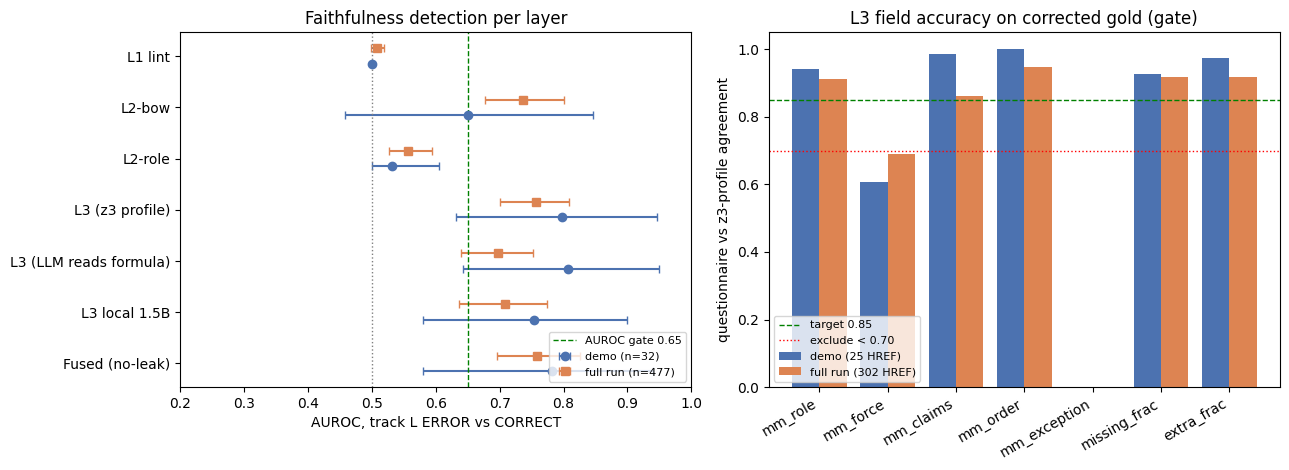


Full-run gates (fused, primary):
  AUROC>=0.65                  value=0.7589  pass=True
  coverage>=0.90               value=0.9203  pass=True
  rewrite_FA<=0.10_per_family  value=0.275  pass=False
  cost<=0.002/item             value=0.0002  pass=True


In [21]:
ref = data["full_run_reference"]
full_auc = ref["primary_L_ERROR_vs_CORRECT_AUROC"]
full_ci = ref["primary_L_ERROR_vs_CORRECT_AUROC_CI95"]
show = [("L1 lint", "l1_any"), ("L2-bow", "l2_bow"), ("L2-role", "l2_role"), ("L3 (z3 profile)", "l3_score"),
        ("L3 (LLM reads formula)", "l3_score_llmformula"), ("L3 local 1.5B", "l3_score_local"),
        ("Fused (no-leak)", "p_fused_H")]

print(f"{'score':<24}{'demo AUROC':>11}{'demo CI95':>18}{'full AUROC':>12}{'full CI95':>18}")
for lbl, k in show:
    e = evals.get(k, {})
    dci = e.get("CI95_cluster") or [None, None]
    fa, fc = full_auc.get(k), full_ci.get(k) or [None, None]
    fmt = lambda v: "   -  " if v is None else f"{v:.3f}"
    print(f"{lbl:<24}{fmt(e.get('AUROC')):>11}{'[' + fmt(dci[0]) + ',' + fmt(dci[1]) + ']':>18}"
          f"{fmt(fa):>12}{'[' + fmt(fc[0]) + ',' + fmt(fc[1]) + ']':>18}")

print("\nL3 field accuracy on HREF (gate):")
print(f"{'field':<14}{'demo':>8}{'full':>8}")
for fld in FT.L3_FIELDS:
    dv = gate.get(fld, {}).get("acc"); fv = ref["L3_gate_primary_acc"].get(fld)
    print(f"{fld:<14}{('-' if dv is None else f'{dv:.3f}'):>8}{('-' if fv is None else f'{fv:.3f}'):>8}")
print("demo gated fields:", gated, "| full-run gated fields:", ref["L3_gated_fields"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
yy = np.arange(len(show))
d_auc = [evals.get(k, {}).get("AUROC") or np.nan for _, k in show]
d_lo = [(evals.get(k, {}).get("CI95_cluster") or [np.nan, np.nan])[0] or np.nan for _, k in show]
d_hi = [(evals.get(k, {}).get("CI95_cluster") or [np.nan, np.nan])[1] or np.nan for _, k in show]
f_auc = [full_auc.get(k) or np.nan for _, k in show]
f_lo = [(full_ci.get(k) or [np.nan, np.nan])[0] or np.nan for _, k in show]
f_hi = [(full_ci.get(k) or [np.nan, np.nan])[1] or np.nan for _, k in show]
ax.errorbar(d_auc, yy + 0.15, xerr=[np.subtract(d_auc, d_lo), np.subtract(d_hi, d_auc)], fmt="o", color="#4C72B0",
            capsize=3, label=f"demo (n={len(prim)})")
ax.errorbar(f_auc, yy - 0.15, xerr=[np.subtract(f_auc, f_lo), np.subtract(f_hi, f_auc)], fmt="s", color="#DD8452",
            capsize=3, label=f"full run (n={ref['n_primary']})")
ax.axvline(0.5, color="grey", ls=":", lw=1); ax.axvline(0.65, color="green", ls="--", lw=1, label="AUROC gate 0.65")
ax.set_yticks(yy); ax.set_yticklabels([s for s, _ in show]); ax.invert_yaxis()
ax.set_xlabel("AUROC, track L ERROR vs CORRECT"); ax.set_xlim(0.2, 1.0); ax.legend(loc="lower right", fontsize=8)
ax.set_title("Faithfulness detection per layer")

ax = axes[1]
xx = np.arange(len(FT.L3_FIELDS))
dv = [gate.get(fld, {}).get("acc") for fld in FT.L3_FIELDS]
fv = [ref["L3_gate_primary_acc"].get(fld) for fld in FT.L3_FIELDS]
ax.bar(xx - 0.2, [np.nan if v is None else v for v in dv], 0.4, color="#4C72B0", label=f"demo ({len(href_ok)} HREF)")
ax.bar(xx + 0.2, [np.nan if v is None else v for v in fv], 0.4, color="#DD8452", label="full run (302 HREF)")
ax.axhline(0.85, color="green", ls="--", lw=1, label="target 0.85"); ax.axhline(0.70, color="red", ls=":", lw=1, label="exclude < 0.70")
ax.set_xticks(xx); ax.set_xticklabels(FT.L3_FIELDS, rotation=30, ha="right"); ax.set_ylim(0, 1.05)
ax.set_ylabel("questionnaire vs z3-profile agreement"); ax.set_title("L3 field accuracy on corrected gold (gate)")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

print("\nFull-run gates (fused, primary):")
for k, v in ref["gates_fused_primary"].items():
    if not isinstance(v, dict):
        continue
    print(f"  {k:<28} value={v.get('value', v.get('worst_family_FA'))}  pass={v.get('pass')}")